# Generate `param_times.json`

In [1]:
import json

import pandas as pd
from rich import print
from sim_tools.distributions import DistributionRegistry

from ambdes import fit_config, plot_metric_kde

In [2]:
TIME_DATA_PATH = "../data/times.csv"
PARAM_TIMES_PATH = "../data/param_times.json"
CHOSEN_TIME_DIST_PATH = "../data/chosen_time_distributions.json"

# Import raw time data
time_data = pd.read_csv(TIME_DATA_PATH)

# Import dictionary detailing chosen distributions and relevant columns
with open(CHOSEN_TIME_DIST_PATH) as f:
    chosen_time_dist = json.load(f)
print(chosen_time_dist)

{
    'mobilisation_time': {'dist': 'Weibull', 'column': 'C0001_Mobilisation_Duration'},
    'time_to_scene': {'dist': 'Erlang', 'column': 'C0004_MobilisationToScene_Duration'},
    'on_scene_time': {'dist': 'Lognormal', 'column': 'C0007_OnScene_Duration'},
    'time_to_hospital': {'dist': 'Gamma', 'column': 'C0172_SceneToDestination_Duration'},
    'handover_time': {'dist': 'Lognormal', 'column': 'C0012_Handover_Duration'},
    'wrap_up_time': {'dist': 'Gamma', 'column': 'C0171_WrapUp_Duration'}
}

In [3]:
# Generate config
config = fit_config(time_data=time_data, metric_config=chosen_time_dist)

print(config)

# Save to JSON file
with open(PARAM_TIMES_PATH, "w") as fp:
    json.dump(config, fp, indent=2)

{
    'mobilisation_time': {
        'C1': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(2.127347196468359), 'beta': np.float64(22.566875572270405)}
        },
        'C2': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(2.9669273833500105), 'beta': np.float64(33.41906777180509)}
        },
        'C3': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(3.765608182338865), 'beta': np.float64(43.914147745696894)}
        },
        'C4': {
            'class_name': 'Weibull',
            'params': {'alpha': np.float64(4.399327571510532), 'beta': np.float64(54.138855280030754)}
        }
    },
    'time_to_scene': {
        'C1': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(198.97375543933887), 'stdev': np.float64(79.75016059602675)}
        },
        'C2': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(209.49883623610057), 'stdev': np.float64(80.29430310204087)}
        },
        'C3': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(219.57202266152362), 'stdev': np.float64(79.94190796992898)}
        },
        'C4': {
            'class_name': 'Erlang',
            'params': {'mean': np.float64(229.97287361845264), 'stdev': np.float64(79.72497268269149)}
        }
    },
    'on_scene_time': {
        'C1': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(799.6102000079844), 'stdev': np.float64(299.7328538713622)}
        },
        'C2': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(809.3391813797775), 'stdev': np.float64(299.62162110540294)}
        },
        'C3': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(818.2887455801994), 'stdev': np.float64(297.3392999289891)}
        },
        'C4': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(830.1790285119333), 'stdev': np.float64(299.12592223814517)}
        }
    },
    'time_to_hospital': {
        'C1': {
            'class_name': 'Gamma',
            'params': {'alpha': 4.641757210321853, 'beta': np.float64(64.88069838061625)}
        },
        'C2': {
            'class_name': 'Gamma',
            'params': {'alpha': 5.021349515569629, 'beta': np.float64(61.96279801748901)}
        },
        'C3': {
            'class_name': 'Gamma',
            'params': {'alpha': 5.392869169315348, 'beta': np.float64(59.43995644733972)}
        },
        'C4': {
            'class_name': 'Gamma',
            'params': {'alpha': 5.707445016763136, 'beta': np.float64(57.67153095232989)}
        }
    },
    'handover_time': {
        'C1': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(401.69188390754124), 'stdev': np.float64(198.84934982157966)}
        },
        'C2': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(410.4876688852576), 'stdev': np.float64(197.82954261192126)}
        },
        'C3': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(420.3226775956284), 'stdev': np.float64(201.60534709239045)}
        },
        'C4': {
            'class_name': 'Lognormal',
            'params': {'mean': np.float64(429.1383309306423), 'stdev': np.float64(198.97277984851414)}
        }
    },
    'wrap_up_time': {
        'C1': {
            'class_name': 'Gamma',
            'params': {'alpha': 4.188528756618028, 'beta': np.float64(35.81218418303792)}
        },
        'C2': {
            'class_name': 'Gamma',
            'params': {'alpha': 4.709314052350785, 'beta': np.float64(34.158413305868834)}
        },
        'C3': {
            'class_name': 'Gamma',
            'params': {'alpha': 5.599857716953801, 'beta': np.float64(30.195409909161246)}
        },
        'C4': {
            'class_name': 'Gamma',
            'params': {'

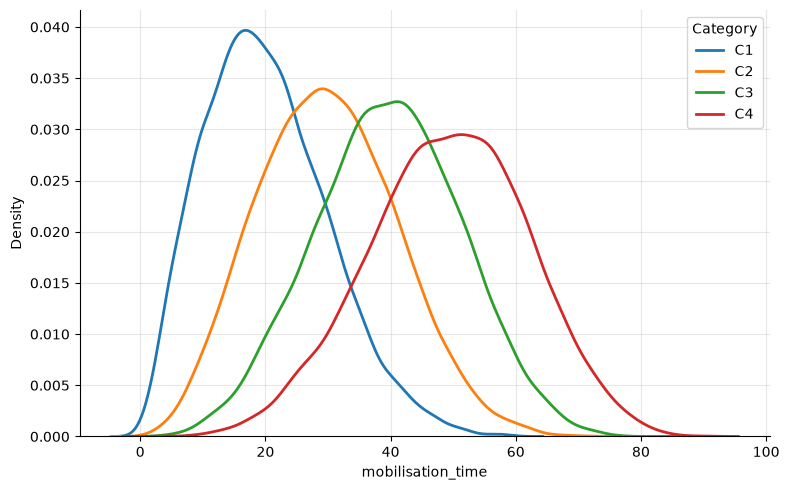

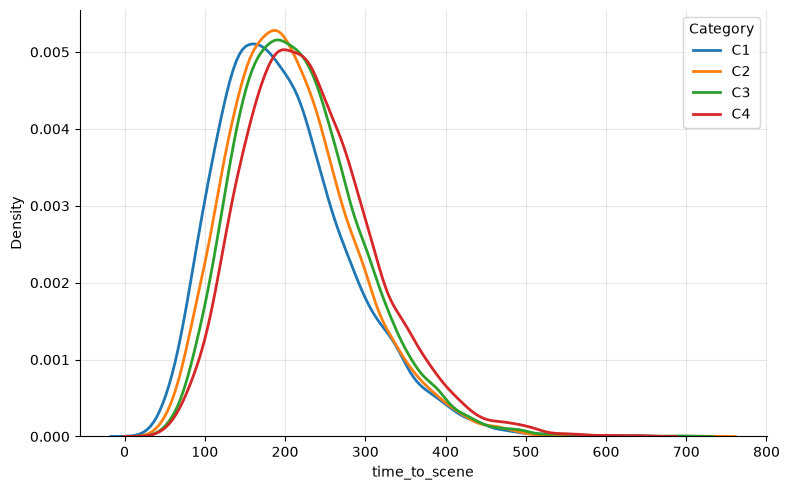

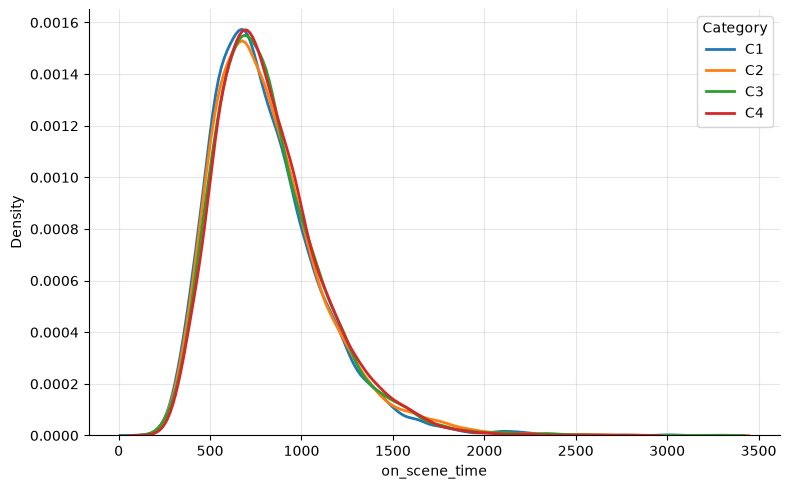

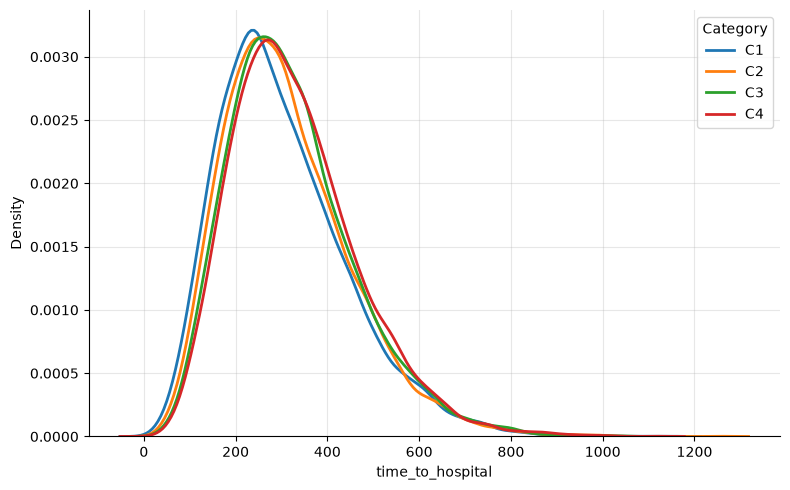

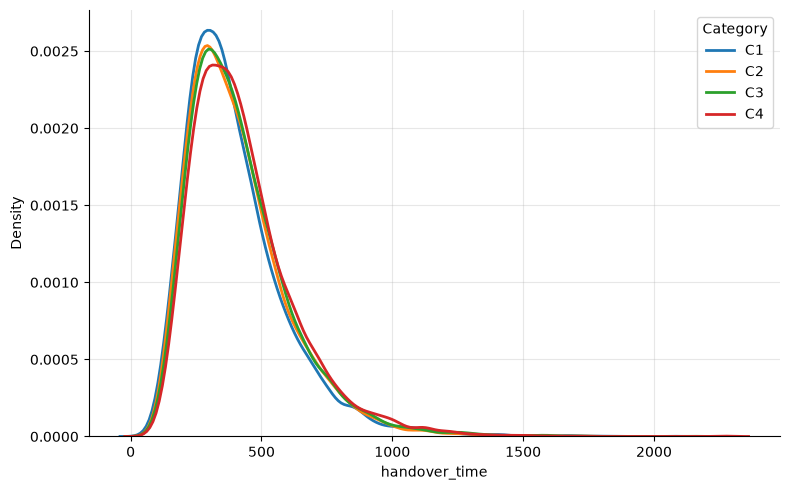

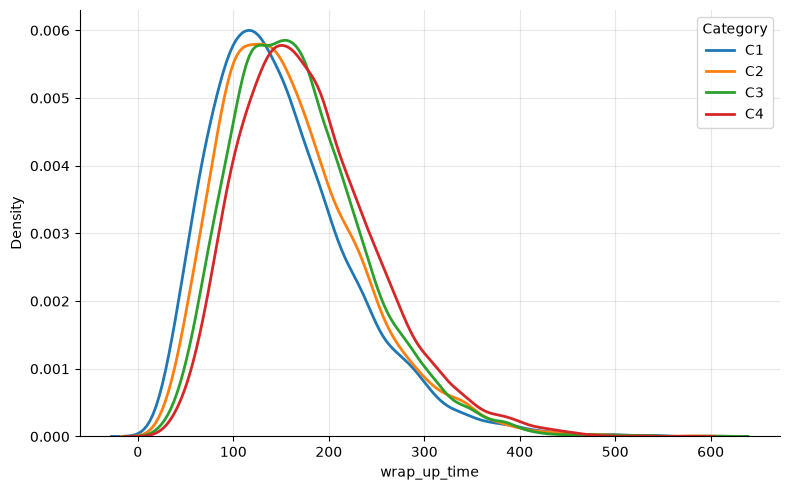

In [4]:
# Create distribution registry
registry = DistributionRegistry.create_batch(
    config, main_seed=42, preserve_structure=True
)

# Generate KDE plots for each metric, by response category
plot_metric_kde(metric="mobilisation_time", registry=registry)
plot_metric_kde(metric="time_to_scene", registry=registry)
plot_metric_kde(metric="on_scene_time", registry=registry)
plot_metric_kde(metric="time_to_hospital", registry=registry)
plot_metric_kde(metric="handover_time", registry=registry)
plot_metric_kde(metric="wrap_up_time", registry=registry)